In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"
df = pd.read_csv(url)

print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info() 

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [5]:
df['Churn'].value_counts() 

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df[df['TotalCharges'] == ' ']

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [8]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [9]:
print(df['TotalCharges'].isnull().sum())

11


In [10]:
df['TotalCharges'] = df['TotalCharges'].fillna(0)

In [11]:
df['ChurnFlag'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [14]:
customers = df[['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
                'PhoneService', 'InternetService', 'Contract', 'PaymentMethod']]

billing = df[['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'ChurnFlag']]

print(customers.shape)
print(billing.shape)

(7043, 9)
(7043, 5)


In [15]:
import sqlite3

conn = sqlite3.connect('churn.db')

customers.to_sql('customers', conn, if_exists='replace', index=False)
billing.to_sql('billing', conn, if_exists='replace', index=False)

print("Tables created successfully")

Tables created successfully


In [16]:
result = pd.read_sql("""
    SELECT c.Contract, COUNT(*) as customer_count, AVG(b.MonthlyCharges) as avg_charge
    FROM customers c
    JOIN billing b ON c.customerID = b.customerID
    GROUP BY c.Contract
""", conn)

print(result)

         Contract  customer_count  avg_charge
0  Month-to-month            3875   66.398490
1        One year            1473   65.048608
2        Two year            1695   60.770413


In [17]:
result = pd.read_sql("""
    SELECT 
        COUNT(*) as total_customers,
        SUM(ChurnFlag) as churned_customers,
        ROUND(100.0 * SUM(ChurnFlag) / COUNT(*), 2) as churn_rate_pct
    FROM billing
""", conn)

print(result)

   total_customers  churned_customers  churn_rate_pct
0             7043               1869           26.54


In [18]:
result = pd.read_sql("""
    SELECT 
        c.Contract,
        COUNT(*) as total_customers,
        SUM(b.ChurnFlag) as churned,
        ROUND(100.0 * SUM(b.ChurnFlag) / COUNT(*), 2) as churn_rate_pct
    FROM customers c
    JOIN billing b ON c.customerID = b.customerID
    GROUP BY c.Contract
    ORDER BY churn_rate_pct DESC
""", conn)

print(result)

         Contract  total_customers  churned  churn_rate_pct
0  Month-to-month             3875     1655           42.71
1        One year             1473      166           11.27
2        Two year             1695       48            2.83


In [19]:
result = pd.read_sql("""
    SELECT 
        c.PaymentMethod,
        COUNT(*) as total_customers,
        ROUND(100.0 * SUM(b.ChurnFlag) / COUNT(*), 2) as churn_rate_pct
    FROM customers c
    JOIN billing b ON c.customerID = b.customerID
    GROUP BY c.PaymentMethod
    ORDER BY churn_rate_pct DESC
""", conn)

print(result)

               PaymentMethod  total_customers  churn_rate_pct
0           Electronic check             2365           45.29
1               Mailed check             1612           19.11
2  Bank transfer (automatic)             1544           16.71
3    Credit card (automatic)             1522           15.24


In [20]:
result = pd.read_sql("""
    SELECT 
        CASE 
            WHEN tenure <= 12 THEN '0-1 year'
            WHEN tenure <= 24 THEN '1-2 years'
            WHEN tenure <= 48 THEN '2-4 years'
            ELSE '4+ years'
        END as tenure_group,
        COUNT(*) as total_customers,
        ROUND(100.0 * SUM(ChurnFlag) / COUNT(*), 2) as churn_rate_pct
    FROM billing
    GROUP BY tenure_group
    ORDER BY churn_rate_pct DESC
""", conn)

print(result)

  tenure_group  total_customers  churn_rate_pct
0     0-1 year             2186           47.44
1    1-2 years             1024           28.71
2    2-4 years             1594           20.39
3     4+ years             2239            9.51


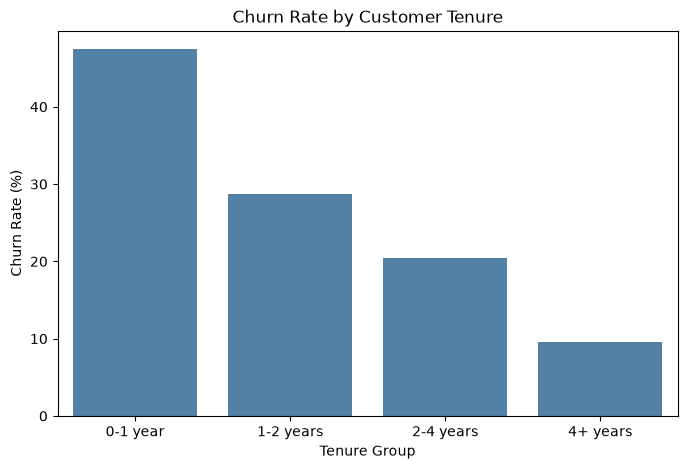

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

tenure_data = pd.read_sql("""
    SELECT 
        CASE 
            WHEN tenure <= 12 THEN '0-1 year'
            WHEN tenure <= 24 THEN '1-2 years'
            WHEN tenure <= 48 THEN '2-4 years'
            ELSE '4+ years'
        END as tenure_group,
        ROUND(100.0 * SUM(ChurnFlag) / COUNT(*), 2) as churn_rate_pct
    FROM billing
    GROUP BY tenure_group
""", conn)

order = ['0-1 year', '1-2 years', '2-4 years', '4+ years']
tenure_data['tenure_group'] = pd.Categorical(tenure_data['tenure_group'], categories=order, ordered=True)
tenure_data = tenure_data.sort_values('tenure_group')

plt.figure(figsize=(8,5))
sns.barplot(data=tenure_data, x='tenure_group', y='churn_rate_pct', color='steelblue')
plt.title('Churn Rate by Customer Tenure')
plt.xlabel('Tenure Group')
plt.ylabel('Churn Rate (%)')
plt.show()

In [22]:
result = pd.read_sql("""
    SELECT 
        CASE WHEN ChurnFlag = 1 THEN 'Churned' ELSE 'Stayed' END as status,
        COUNT(*) as customers,
        ROUND(AVG(MonthlyCharges), 2) as avg_monthly_charge,
        ROUND(SUM(MonthlyCharges), 2) as total_monthly_revenue_at_risk
    FROM billing
    GROUP BY ChurnFlag
""", conn)

print(result)

    status  customers  avg_monthly_charge  total_monthly_revenue_at_risk
0   Stayed       5174               61.27                      316985.75
1  Churned       1869               74.44                      139130.85


In [24]:
monthly_revenue_lost = 139130.85
annual_revenue_lost = monthly_revenue_lost * 12
print(f"Estimated annual recurring revenue lost to churn: ${annual_revenue_lost:,.2f}")

Estimated annual recurring revenue lost to churn: $1,669,570.20


In [25]:
model_df = pd.read_sql("""
    SELECT 
        c.*, 
        b.tenure, b.MonthlyCharges, b.TotalCharges, b.ChurnFlag
    FROM customers c
    JOIN billing b ON c.customerID = b.customerID
""", conn)

print(model_df.shape)
model_df.head()

(7043, 13)


,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,InternetService,Contract,PaymentMethod,tenure,MonthlyCharges,TotalCharges,ChurnFlag
0,7590-VHVEG,Female,0,Yes,No,No,DSL,Month-to-month,Electronic check,1,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,Yes,DSL,One year,Mailed check,34,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,Yes,DSL,Month-to-month,Mailed check,2,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,No,DSL,One year,Bank transfer (automatic),45,42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,Yes,Fiber optic,Month-to-month,Electronic check,2,70.70,151.65,1


In [26]:
features_df = model_df.drop(columns=['customerID'])

In [27]:
features_df = pd.get_dummies(features_df, drop_first=True)

In [28]:
print(features_df.shape)
features_df.columns.tolist()

(7043, 16)


['SeniorCitizen',
 'tenure',
 'MonthlyCharges',
 'TotalCharges',
 'ChurnFlag',
 'gender_Male',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'Contract_One year',
 'Contract_Two year',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

In [29]:
X = features_df.drop(columns=['ChurnFlag'])
y = features_df['ChurnFlag']

print(X.shape, y.shape)

(7043, 15) (7043,)


In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (5634, 15)
Test size: (1409, 15)


In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

print("Model trained successfully")

Model trained successfully


In [35]:
baseline_accuracy = 1 - y_test.mean()
print(f"Accuracy if we just guessed 'No churn' every time: {baseline_accuracy:.2%}")

Accuracy if we just guessed 'No churn' every time: 73.46%


In [36]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = log_model.predict(X_test_scaled)
y_pred_proba = log_model.predict_proba(X_test_scaled)[:, 1]  # probability of churn

print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba):.3f}")

              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.62      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409


Confusion Matrix:
[[914 121]
 [175 199]]

ROC-AUC Score: 0.838


In [37]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42)
rf_model.fit(X_train, y_train)  # Note: no scaling needed for tree-based models

y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print(f"\nROC-AUC Score: {roc_auc_score(y_test, y_pred_proba_rf):.3f}")

              precision    recall  f1-score   support

           0       0.84      0.89      0.86      1035
           1       0.64      0.52      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.79      1409


Confusion Matrix:
[[925 110]
 [181 193]]

ROC-AUC Score: 0.842


In [38]:
importances = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importances)

                                  feature  importance
1                                  tenure    0.219638
3                            TotalCharges    0.193168
2                          MonthlyCharges    0.168578
8             InternetService_Fiber optic    0.092545
13         PaymentMethod_Electronic check    0.076498
11                      Contract_Two year    0.070505
10                      Contract_One year    0.039670
9                      InternetService_No    0.033468
6                          Dependents_Yes    0.019843
5                             Partner_Yes    0.019067
4                             gender_Male    0.018911
0                           SeniorCitizen    0.018549
12  PaymentMethod_Credit card (automatic)    0.011115
14             PaymentMethod_Mailed check    0.010379
7                        PhoneService_Yes    0.008068


In [39]:
result = pd.read_sql("""
    SELECT 
        InternetService,
        COUNT(*) as total_customers,
        ROUND(100.0 * SUM(ChurnFlag) / COUNT(*), 2) as churn_rate_pct
    FROM customers c
    JOIN billing b ON c.customerID = b.customerID
    GROUP BY InternetService
    ORDER BY churn_rate_pct DESC
""", conn)

print(result)

  InternetService  total_customers  churn_rate_pct
0     Fiber optic             3096           41.89
1             DSL             2421           18.96
2              No             1526            7.40


In [40]:

X_full = X  # all features, all 7043 customers
all_risk_scores = rf_model.predict_proba(X_full)[:, 1]

risk_df = pd.DataFrame({
    'customerID': model_df['customerID'],
    'actual_churn': model_df['ChurnFlag'],
    'MonthlyCharges': model_df['MonthlyCharges'],
    'churn_risk_score': all_risk_scores
})

risk_df = risk_df.sort_values('churn_risk_score', ascending=False)
risk_df.head(10)

,customerID,actual_churn,MonthlyCharges,churn_risk_score
5872,4550-EVXNY,1,69.65,0.941898
1651,8580-AECUZ,1,79.10,0.931542
1976,9497-QCMMS,1,93.55,0.931186
4800,9300-AGZNL,1,94.00,0.931056
4349,7903-CMPEY,1,80.30,0.925412
2191,3988-RQIXO,1,91.30,0.922594
3310,9885-CSMWE,1,78.45,0.920422
1371,6567-HOOPW,1,79.20,0.919845
1600,3068-OMWZA,1,88.80,0.919416
287,5583-SXDAG,1,70.00,0.918518


In [41]:
top_20_pct_cutoff = int(len(risk_df) * 0.20)
targeted_customers = risk_df.head(top_20_pct_cutoff)

print(f"Targeting {len(targeted_customers)} customers")
print(f"Of these, {targeted_customers['actual_churn'].sum()} actually churned")
print(f"Capture rate: {100 * targeted_customers['actual_churn'].sum() / risk_df['actual_churn'].sum():.1f}% of all churners")

Targeting 1408 customers
Of these, 1097 actually churned
Capture rate: 58.7% of all churners


In [42]:
revenue_at_risk_targeted = targeted_customers[targeted_customers['actual_churn']==1]['MonthlyCharges'].sum()
annual_revenue_at_risk_targeted = revenue_at_risk_targeted * 12

print(f"Monthly revenue from churners caught by targeting: ${revenue_at_risk_targeted:,.2f}")
print(f"Annualized: ${annual_revenue_at_risk_targeted:,.2f}")

Monthly revenue from churners caught by targeting: $84,985.95
Annualized: $1,019,831.40


In [43]:

offer_cost_per_customer = 50       
retention_success_rate = 0.30    

customers_targeted = len(targeted_customers)
actual_churners_in_target = targeted_customers['actual_churn'].sum()

total_campaign_cost = customers_targeted * offer_cost_per_customer
customers_saved = actual_churners_in_target * retention_success_rate
revenue_saved_monthly = customers_saved * targeted_customers[targeted_customers['actual_churn']==1]['MonthlyCharges'].mean()
revenue_saved_annual = revenue_saved_monthly * 12

print(f"Campaign cost (targeting {customers_targeted} customers): ${total_campaign_cost:,.2f}")
print(f"Estimated customers retained: {customers_saved:.0f}")
print(f"Estimated annual revenue saved: ${revenue_saved_annual:,.2f}")
print(f"Estimated ROI: {(revenue_saved_annual - total_campaign_cost) / total_campaign_cost:.1%}")

Campaign cost (targeting 1408 customers): $70,400.00
Estimated customers retained: 329
Estimated annual revenue saved: $305,949.42
Estimated ROI: 334.6%
